# Descriptive analyses of SIRTUIN6

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

from config.ml_params import TARGET
from config.setting import FIGURES_PATH, RAW_FILE_PATH, figure_path

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(RAW_FILE_PATH)
features = df.drop(columns=TARGET).select_dtypes("number")

## Descriptive statistics

In [2]:
summary = features.describe().T
summary["skew"] = features.skew()
summary["kurtosis"] = features.kurt()
summary["missing"] = features.isna().sum()
summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,missing
SC-5,100.0,0.420488,0.195124,0.083333,0.282118,0.393350,0.532954,0.918546,0.614475,-0.163780,0
SP-6,100.0,4.429250,1.403348,2.091810,3.345093,4.107115,5.302952,7.641920,0.454047,-0.623552,0
SHBd,100.0,0.356504,0.339313,0.000000,0.000000,0.373387,0.482501,1.465000,1.006485,1.009752,0
minHaaCH,100.0,0.443628,0.138964,0.000000,0.429809,0.467655,0.505934,0.720723,-2.105125,5.107396,0
maxwHBa,100.0,1.919511,0.522992,0.000000,1.839850,2.020210,2.161543,3.778650,-1.800842,6.983559,0
FMF,100.0,0.376232,0.072255,0.153846,0.326531,0.376024,0.423240,0.536585,-0.219893,0.065013,0


In [3]:
counts = df[TARGET].value_counts()
pd.DataFrame({"count": counts, "share": counts / len(df)})

,count,share
Class,,
High_BFE,50,0.5
Low_BFE,50,0.5


In [4]:
df.groupby(TARGET).agg(["mean", "std"]).T

Class          High_BFE   Low_BFE
SC-5     mean  0.492615  0.348360
         std   0.179169  0.184945
SP-6     mean  5.373688  3.484811
         std   1.162423  0.898553
SHBd     mean  0.354257  0.358750
         std   0.321128  0.359836
minHaaCH mean  0.480763  0.406494
         std   0.048480  0.183987
maxwHBa  mean  1.997238  1.841785
         std   0.180647  0.712503
FMF      mean  0.419945  0.332519
         std   0.054440  0.060702

## Distributions

In [5]:
normality = pd.DataFrame(
    {col: stats.shapiro(features[col].dropna()) for col in features},
    index=["statistic", "p_value"],
).T
normality["normal"] = normality["p_value"] > 0.05
normality

,statistic,p_value,normal
SC-5,0.957137,2.526408e-03,False
SP-6,0.960808,4.593859e-03,False
SHBd,0.868163,5.914516e-08,False
minHaaCH,0.735328,3.900631e-12,False
maxwHBa,0.717506,1.407048e-12,False
FMF,0.992507,8.566507e-01,True


In [6]:
classes = [group for _, group in df.groupby(TARGET)]
class_comparison = pd.DataFrame(
    {col: stats.mannwhitneyu(classes[0][col], classes[1][col]) for col in features},
    index=["statistic", "p_value"],
).T
class_comparison

,statistic,p_value
SC-5,1849.0,3.684117e-05
SP-6,2263.0,2.951956e-12
SHBd,1285.5,8.058861e-01
minHaaCH,1564.0,3.065089e-02
maxwHBa,1261.0,9.422954e-01
FMF,2157.5,4.020752e-10


## Figures

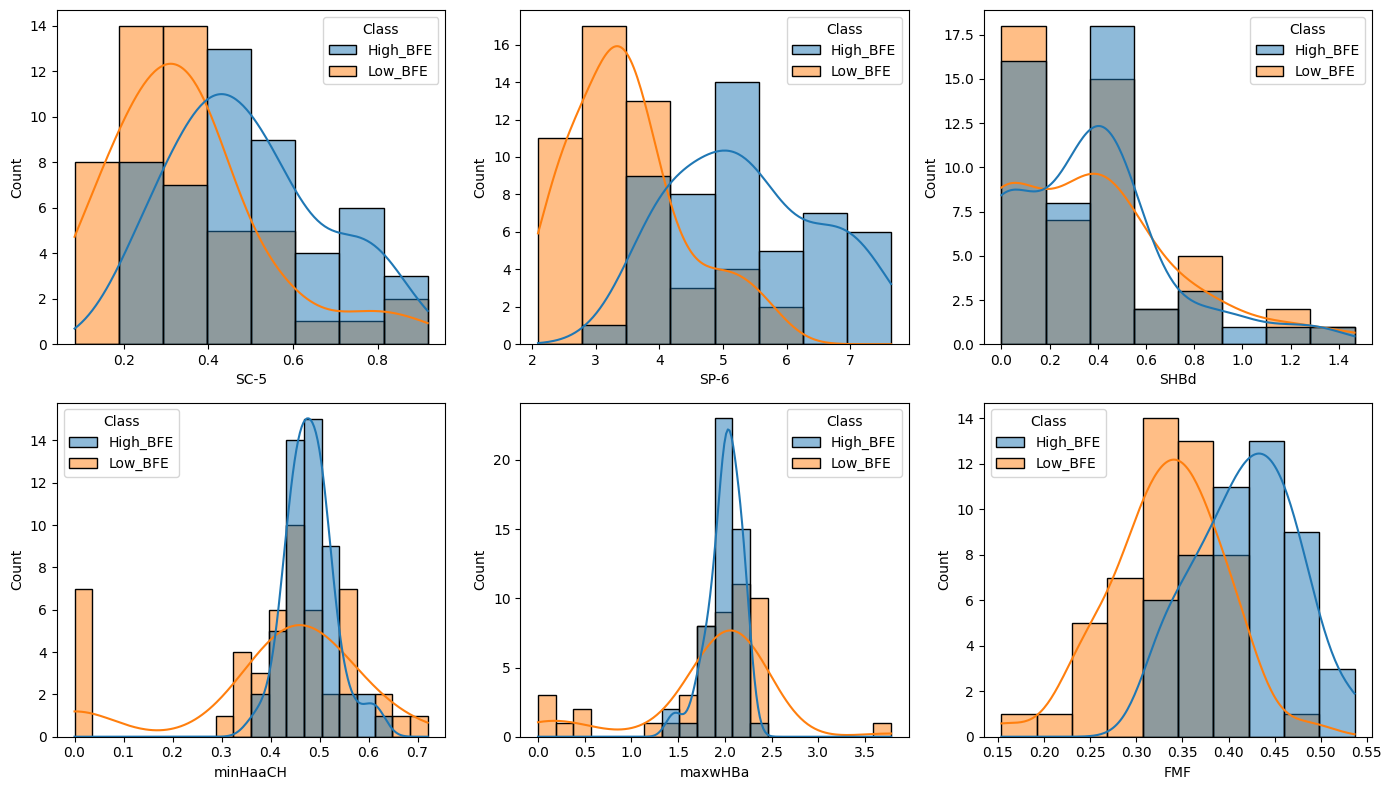

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, features):
    sns.histplot(data=df, x=col, hue=TARGET, kde=True, ax=ax)
fig.tight_layout()
fig.savefig(figure_path("histograms"), dpi=150)
plt.show()

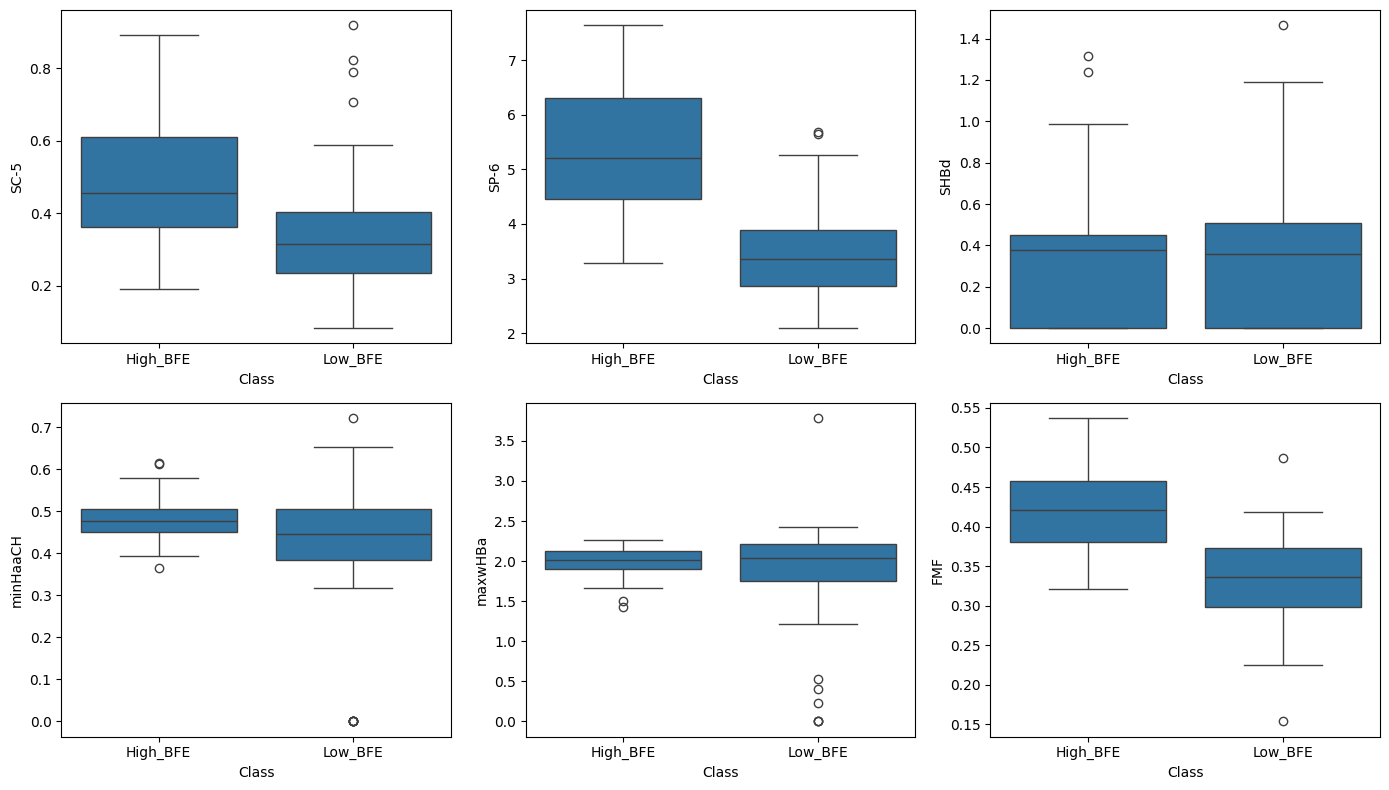

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, features):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
fig.tight_layout()
fig.savefig(figure_path("boxplots"), dpi=150)
plt.show()

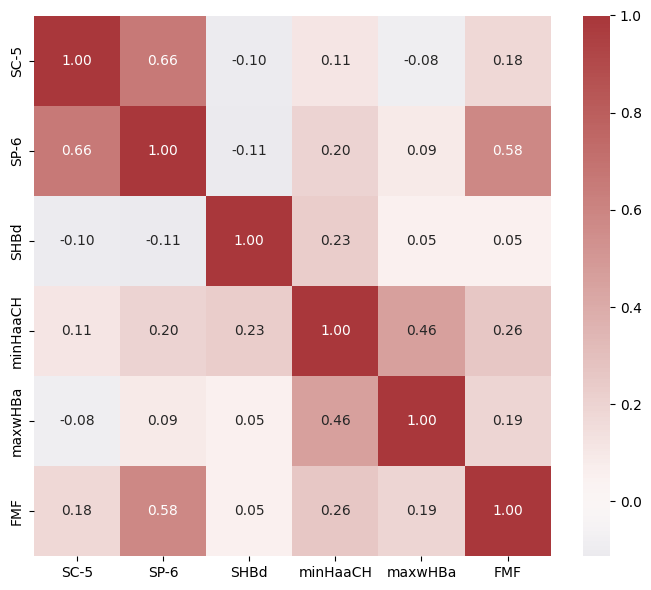

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(features.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
fig.tight_layout()
fig.savefig(figure_path("correlations"), dpi=150)
plt.show()